---------- New Run ----------


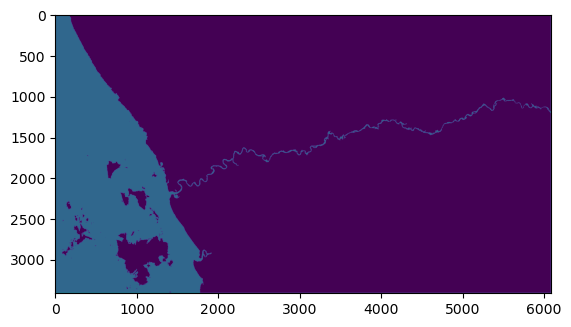

In [3]:
from rivgraph.classes import river
import matplotlib.pyplot as plt
import os

# Define the path to the georeferenced binary image.
mask_path = r"C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\L82025r_resampled.tif"
#mask_path = r"C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\L82020r_reprojected.tif"
# Results will be saved with this name
name = 'k2025'

# Where to store RivGraph-generated geotiff and geovector files.
results_folder = r"C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\mark1planforms\riv3"

# Set the exit sides of the river relative to the image. In this case, the
# Brahmaputra is "entering" the image from the North and "exiting" the
# image from the South.
es = 'EW' # The first character is the upstream side

# Boot up the river class! We set verbose=True to see progress of processing.
kanektok = river(name, mask_path, results_folder, exit_sides=es, verbose=True)

# The mask has been re-binarized and stored as an attribute of brahma:
plt.imshow(kanektok.Imask)

Skeletonizing mask...
skeletonization is done.


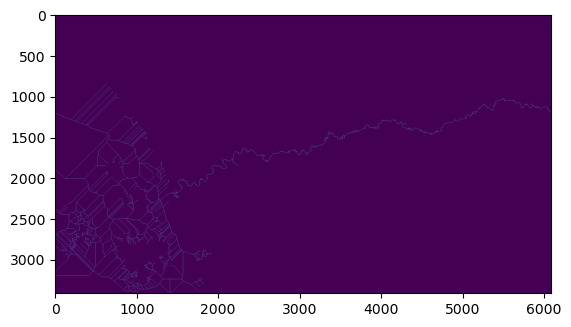

In [4]:
# Simply use the skeletonize() method.
kanektok.skeletonize()

# The skeletonized image is stored as an attribute to the brahm class. Let's take a look.
plt.imshow(kanektok.Iskel)

In [5]:
# We use the write_geotiff() method with the 'skeleton' option.
kanektok.to_geotiff('skeleton')

Geotiff written to C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\mark1planforms\riv3\k2025_skel.tif.


In [6]:
# Simply use the compute_network() method.
kanektok.compute_network()

Resolving links and nodes...
links and nodes have been resolved.


In [7]:
# Now we can see that the "links" and "nodes" dictionaries ahve been added
# as attributes to the brahma class:
links = kanektok.links
nodes = kanektok.nodes
print('links: {}'.format(links.keys()))
print('nodes: {}'.format(nodes.keys()))

links: dict_keys(['idx', 'conn', 'id', 'n_networks'])
nodes: dict_keys(['idx', 'conn', 'id'])


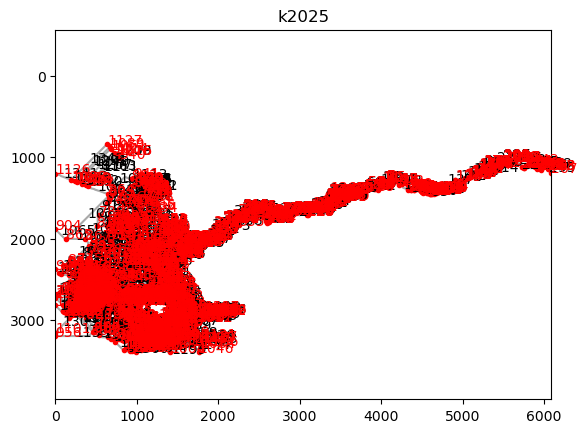

In [8]:
kanektok.plot('network')

In [9]:
kanektok.to_geovectors('network', ftype='json')

# Let's see where the network geovector files were written:
print(kanektok.paths['links'])
print(kanektok.paths['nodes'])

C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\mark1planforms\riv3\k2025_links.json
C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\mark1planforms\riv3\k2025_nodes.json


In [10]:
kanektok.prune_network()

# We see that 'inlets' and 'outlets' have been added to the nodes dictionary:
print(kanektok.nodes.keys())

# We can get the node ids of the inlets and outlets
print('inlets:', kanektok.nodes['inlets'])
print('outlets:', kanektok.nodes['outlets'])

dict_keys(['idx', 'conn', 'id', 'inlets', 'outlets'])
inlets: [267]
outlets: [904, 945, 956, 1101, 1126, 1134, 1197, 1198]


Computing distance transform...
distance transform done.
Computing link widths and lengths...
link widths and lengths computed.


Text(0.5, 1.0, 'Histogram of link lengths')

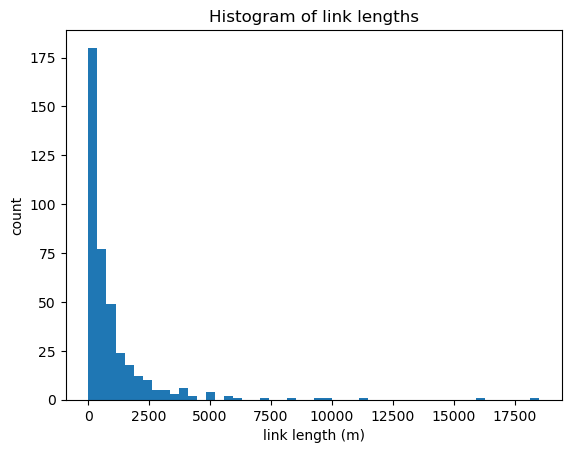

In [11]:
kanektok.compute_link_width_and_length()

# Let's look at histograms of link widths and lengths:
trash = plt.hist(kanektok.links['len_adj'], bins=50)
plt.ylabel('count')
plt.xlabel('link length (m)')
plt.title('Histogram of link lengths')

In [12]:
# Note that we provide no arguments to the compute_mesh() function.
kanektok.compute_mesh(smoothing=0.2)


Computing centerline...
centerline computation is done.
Computing link widths and lengths...
link widths and lengths computed.
Generating mesh...
mesh generation is done.


In [13]:
print(kanektok.centerline)

(array([-17955817.49998705, -17955832.49998705, -17955847.49998705, ...,
       -18031612.49998705, -18031597.49998705, -18031582.49998705]), array([8359236.32930407, 8359236.32930407, 8359236.32930407, ...,
       8356641.32930407, 8356641.32930407, 8356656.32930407]))


In [14]:
kanektok.to_geovectors('centerline', ftype='json')

In [15]:
kanektok.to_geovectors('mesh', ftype='json')

In [16]:
print(kanektok.paths['meshlines'])
print(kanektok.paths['meshpolys'])

C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\mark1planforms\riv3\k2025_meshlines.json
C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\mark1planforms\riv3\k2025_meshpolys.json


In [17]:
# grid_spacing
print('grid_spacing: {}'.format(kanektok.avg_chan_width))
# buf_halfwidth
print('buf_halfwidth: {}'.format(kanektok.max_valley_width_pixels * kanektok.pixlen * 1.1))
# smoothing by default was 0.1
print('smoothing: {}'.format(0.1))

grid_spacing: 1915.3110939530318
buf_halfwidth: 38543.5055618972
smoothing: 0.1


In [18]:
kanektok.assign_flow_directions()


Setting link directionality...
No file found for manually setting link directions.
A .csv file for manual fixes to link directions at C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\mark1planforms\riv3\k2025_fixlinks.csv.


C:\Users\jon20\anaconda3\envs\rivgraph_env\lib\site-packages\rivgraph\rivers\river_directionality.py:78: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  links, nodes = directional_info(links, nodes, Imask, pixlen, exit_sides,


KeyError: 451

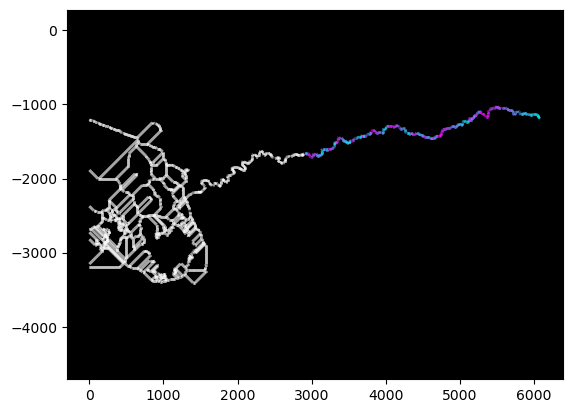

In [19]:
kanektok.plot('directions')


In [20]:
kanektok.to_geotiff('directions')


Geotiff written to C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\mark1planforms\riv3\k2025_link_directions.tif.


In [21]:
kanektok.to_geovectors(export='links', ftype='shp')

C:\Users\jon20\anaconda3\envs\rivgraph_env\lib\site-packages\rivgraph\io_utils.py:262: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(path_export, driver=get_driver(path_export))


In [ ]:
kanektok.centerline

In [ ]:
import matplotlib.pyplot as plt
plt.plot(*zip(*kanektok.centerline))
plt.show()